# APLICACIÓN MODELO A EN IMAGENES DE SEPTIEMBRE DE 2021 PARA DETECTAR INCENDIOS DE SEPTIEMBRE DE 2021 #

In [10]:
# =========================================================
# INFERENCIA ESPACIAL RF (ModelA) — Sentinel-1 + Landsat 8
# Salidas: probabilidad + binario + validación con puntos
# =========================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.errors import RasterioIOError
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------------
# CONFIG (AJUSTA)
# ---------------------------------------------------------

MODEL_PKL = r"C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\outputs\outputs_rf_pipeline_260507-Copy1\modelo_RF_A_260507-Copy1.pkl" 

L8_TIF = r"D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\TIFF\L8\L8_2021_sep_oct.tif"    # raster L8 con descriptions (incluye índices)
S1_TIF = r"D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\TIFF\S1_V2_PREPOST\S1_2021-09-21_3_prepost_indices.tif"     # raster S1 con orden: VV, VH, Angle, Ratio, Diff

OUT_DIR = r"D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\TIFF\outputs_inferencia_ModelA_26_09_14"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PROB = os.path.join(OUT_DIR, "rf_probabilidad_quemado_26_09_15.tif")
OUT_BIN  = os.path.join(OUT_DIR, "rf_quemado_binario_26_09_15.tif")

# Puntos reales (presencia). Idealmente en el mismo CRS del raster o reproyectables.

PATH_FIRE_GDB = r"D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\SHP\incendios_con_orbitas.gpkg"
FIRE_POINTS = "Prueba_ModeloA_Septiem_26_09_11"


#FIRE_POINTS = r"D:\...\incendios_reales.shp"  # debe tener geometry
# (Opcional) puntos ausencia para métricas completas:
ABS_POINTS = r"D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\SHP\Prueba_ModeloA_ NoIncendios_26_09_11_.shp"  # r"D:\...\ausencias.shp" or None



THRESHOLD = 0.6 # umbral binario 0.50 inicialmente e incrementar en caso de sobreestimar las áreas quemadas. En mi caso rf_quemado_binario_26_09_14.tif con THRESHOLD = 0.6 fue 
#el que me genero un modelo binario más conservado sin sobreestimar la totalidad del área como quemada. rf_quemado_binario_26_09_14_v2.tif con THRESHOLD = 0.3 y rf_quemado_binario_26_09_14_v3.tif
# con THRESHOLD = 0.5 me sobreestiman la totalidad del área como cicatriz


In [12]:
# Features EXACTAS como entrenaste (FEATURES)
FEATURES = ["RED","NIR","SWIR_1","SWIR_2","NDVI","EVI","NBR","VV","VH","angle","VVVH_ratio", "VV_Difference", "VH_Difference", "VHVV_Difference"]

# Landsat 8: mapping de nombres en descriptions -> nombre final del modelo
# (Aquí asumimos que las descriptions ya son SR_B4, SR_B5, ... NDVI, EVI, NBR, IMG_COUNT)
L8_BAND_MAP = {
    "SR_B4": "RED",
    "SR_B5": "NIR",
    "SR_B6": "SWIR_1",
    "SR_B7": "SWIR_2",
    "NDVI": "NDVI",
    "EVI": "EVI",
    "NBR": "NBR",
}

# Sentinel-1: orden fijo (tu caso)
# 1=VV, 2=VH, 3=Angle, 4=VVVH_ratio, 5=VV_Difference
S1_BAND_IDX = {"VV": 1, "VH": 2, "angle": 3, "VVVH_ratio": 4, "VV_Difference": 5, "VH_Difference": 6, "VHVV_Difference": 7}

In [14]:
# ---------------------------------------------------------
# 0) Cargar modelo
# ---------------------------------------------------------
import joblib
modelA = joblib.load(MODEL_PKL)

# Sanity: el modelo debe ser clasificador con predict_proba
assert hasattr(modelA, "predict_proba"), "El modelo no tiene predict_proba()."


# ---------------------------------------------------------
# Helpers críticos
# ---------------------------------------------------------
def _read_l8_stack(l8_path: str, band_map: dict) -> tuple[np.ndarray, dict]:
    """
    Lee Landsat 8 multibanda por 'descriptions' y arma stack en el orden del modelo.
    Retorna:
      - arr_l8: (H, W, n_l8_features) float32
      - meta_ref: metadata rasterio para georreferenciación (CRS, transform, shape)
    """
    with rasterio.open(l8_path) as src:
        desc = list(src.descriptions)
        if any(d is None for d in desc):
            raise ValueError("L8: hay bandas sin 'descriptions'. Tu pipeline requiere descriptions para mapear nombres.")

        # Validar que todas las bandas requeridas existan
        missing = [k for k in band_map.keys() if k not in desc]
        if missing:
            raise ValueError(f"L8: faltan bandas en descriptions: {missing}. Disponibles: {desc}")

        # Leer cada banda requerida y renombrar a output
        bands_out = []
        out_names = []
        for band_in, band_out in band_map.items():
            idx = desc.index(band_in) + 1  # rasterio 1-based
            b = src.read(idx).astype("float32")
            nod = src.nodata
            if nod is not None:
                b[b == nod] = np.nan
            b[~np.isfinite(b)] = np.nan
            bands_out.append(b)
            out_names.append(band_out)

        arr = np.stack(bands_out, axis=-1)  # (H,W,C)
        meta = src.meta.copy()
        meta_ref = {
            "crs": src.crs,
            "transform": src.transform,
            "width": src.width,
            "height": src.height,
            "dtype": "float32",
        }

    return arr, meta_ref


def _read_s1_stack(s1_path: str, band_idx: dict, ref_shape: tuple[int, int]) -> np.ndarray:
    """
    Lee Sentinel-1 usando índices 1-based y ajusta/recorta la matriz 
    al tamaño de referencia (ref_shape) si hay discrepancias de dimensión.
    Retorna stack (H, W, 7) float32.
    """
    with rasterio.open(s1_path) as src:
        H, W = ref_shape
        
        bands = []
        for name in ["VV", "VH", "angle", "VVVH_ratio", "VV_Difference", "VH_Difference", "VHVV_Difference"]:
            idx = band_idx[name]
            
            # Opción A: Leer con reallocación/resampling directo usando out_shape
            b = src.read(idx, out_shape=(H, W), resampling=Resampling.nearest).astype("float32")
            
            nod = src.nodata
            if nod is not None:
                b[b == nod] = np.nan
            b[~np.isfinite(b)] = np.nan
            bands.append(b)

        arr = np.stack(bands, axis=-1)

    return arr


def _build_feature_cube(l8_cube: np.ndarray, s1_cube: np.ndarray, features: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """
    Une cubos L8 y S1 en un solo cubo con el orden EXACTO de FEATURES.
    Retorna:
      - X2d: (N_valid, n_features)
      - valid_mask: (H,W) bool
    """
    H, W, _ = l8_cube.shape
    assert s1_cube.shape[:2] == (H, W), "S1 y L8 no coinciden en H,W."

    # Crear diccionario nombre->matriz (H,W)
    d = {}
    # L8_cube viene en el orden de L8_BAND_MAP.values() (RED, NIR, ...)
    l8_names = list(L8_BAND_MAP.values())
    for i, nm in enumerate(l8_names):
        d[nm] = l8_cube[:, :, i]

    # S1
    d["VV"] = s1_cube[:, :, 0]
    d["VH"] = s1_cube[:, :, 1]
    d["angle"] = s1_cube[:, :, 2]
    d["VVVH_ratio"] = s1_cube[:, :, 3] 
    d["VV_Difference"] = s1_cube[:, :, 4]
    d["VH_Difference"] = s1_cube[:, :, 5]
    d["VHVV_Difference"] = s1_cube[:, :, 6]

    # Stack final por FEATURES
    stack = np.stack([d[nm] for nm in features], axis=-1).astype("float32")  # (H,W,F)

    # máscara de píxeles válidos: TODOS los features finitos
    valid_mask = np.isfinite(stack).all(axis=-1)  # (H,W)

    # a 2D solo válidos
    X2d = stack[valid_mask, :]  # (N_valid,F)

    return X2d, valid_mask


def _predict_probability(model, X2d: np.ndarray) -> np.ndarray:
    """
    predict_proba -> prob clase 1 (presencia/quemado)
    """
    proba = model.predict_proba(X2d)
    # Asumimos clases [0,1] (scikit-learn usual). Por seguridad:
    if hasattr(model, "classes_"):
        classes = list(model.classes_)
        if 1 in classes:
            idx1 = classes.index(1)
        else:
            # si label positivo no es 1, toma última clase como "positiva" (no ideal)
            idx1 = -1
    else:
        idx1 = 1
    return proba[:, idx1].astype("float32")


def _write_geotiff(out_path: str, arr2d: np.ndarray, meta_ref: dict, nodata_val: float, dtype: str):
    """
    Escribe un raster (H,W) con CRS y transform de referencia.
    """
    H, W = arr2d.shape
    meta = {
        "driver": "GTiff",
        "height": H,
        "width": W,
        "count": 1,
        "crs": meta_ref["crs"],
        "transform": meta_ref["transform"],
        "dtype": dtype,
        "nodata": nodata_val,
        "compress": "deflate",
        "predictor": 2 if dtype in ("float32", "float64") else 1,
    }
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(arr2d.astype(dtype), 1)


def _sample_raster_at_points(raster_path: str, gdf_pts: gpd.GeoDataFrame) -> np.ndarray:
    """
    Muestra valores de un raster en puntos (devuelve array N).
    """
    with rasterio.open(raster_path) as src:
        pts = gdf_pts.to_crs(src.crs)
        coords = [(geom.x, geom.y) for geom in pts.geometry]
        vals = np.array([v[0] for v in src.sample(coords, indexes=1)], dtype="float32")
        return vals


# ---------------------------------------------------------
# 1) INFERENCIA: construir cubo, predecir, reconstruir, exportar
# ---------------------------------------------------------
try:
    l8_cube, meta_ref = _read_l8_stack(L8_TIF, L8_BAND_MAP)
except RasterioIOError as e:
    raise RuntimeError(f"No pude abrir L8: {e}")

H, W = l8_cube.shape[0], l8_cube.shape[1]

try:
    s1_cube = _read_s1_stack(S1_TIF, S1_BAND_IDX, ref_shape=(H, W))
except RasterioIOError as e:
    raise RuntimeError(f"No pude abrir S1: {e}")

# Construir dataset de predicción
X2d, valid_mask = _build_feature_cube(l8_cube, s1_cube, FEATURES)

print(f"Pixels totales: {H*W:,}")
print(f"Pixels válidos (todos los features finitos): {int(valid_mask.sum()):,} ({100*valid_mask.mean():.2f}%)")
print(f"Features: {len(FEATURES)} -> {FEATURES}")

# Predicción de probabilidad para los válidos
p_valid = _predict_probability(modelA, X2d)

# Reconstrucción a (H,W) con nodata para inválidos
prob = np.full((H, W), np.nan, dtype="float32")
prob[valid_mask] = p_valid

# Binario por umbral
#burn_bin = np.full((H, W), 0, dtype="uint8")
#burn_bin[valid_mask] = (prob[valid_mask] >= THRESHOLD).astype("uint8")

burn_bin = np.full_like(prob, fill_value=255, dtype="uint8")
burn_bin[valid_mask] = (prob[valid_mask] >= THRESHOLD).astype("uint8")

# Exportar GeoTIFF
_write_geotiff(OUT_PROB, prob, meta_ref, nodata_val=np.nan, dtype="float32")
_write_geotiff(OUT_BIN, burn_bin, meta_ref, nodata_val=255, dtype="uint8")  # 255 como nodata en binario si quieres

print("OK export:")
print(" - Prob:", OUT_PROB)
print(" - Bin :", OUT_BIN)

Pixels totales: 4,861,220
Pixels válidos (todos los features finitos): 3,639,483 (74.87%)
Features: 14 -> ['RED', 'NIR', 'SWIR_1', 'SWIR_2', 'NDVI', 'EVI', 'NBR', 'VV', 'VH', 'angle', 'VVVH_ratio', 'VV_Difference', 'VH_Difference', 'VHVV_Difference']
OK export:
 - Prob: D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\TIFF\outputs_inferencia_ModelA_26_09_14\rf_probabilidad_quemado_26_09_15.tif
 - Bin : D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\TIFF\outputs_inferencia_ModelA_26_09_14\rf_quemado_binario_26_09_15.tif


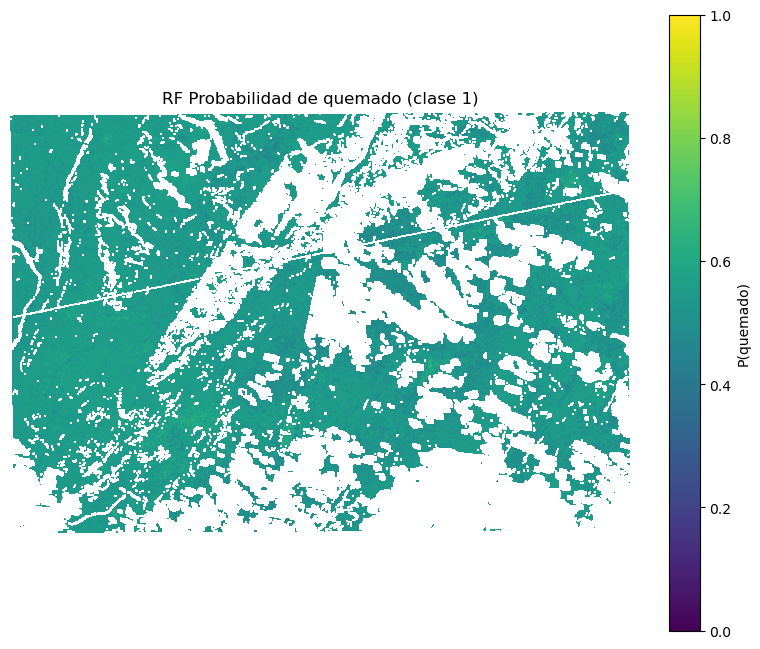

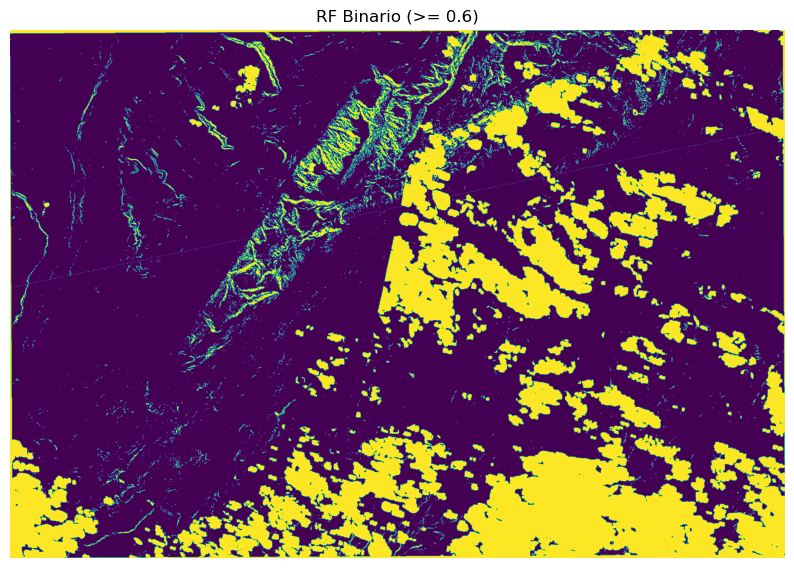

In [15]:
# ---------------------------------------------------------
# 2) Visualización rápida (matplotlib)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.imshow(prob, vmin=0, vmax=1)
plt.title("RF Probabilidad de quemado (clase 1)")
plt.colorbar(label="P(quemado)")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(burn_bin)
plt.title(f"RF Binario (>= {THRESHOLD})")
plt.axis("off")
plt.show()

C:\Users\Equipo\anaconda3\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column acq_date, 2021-07-09T00:00:00.0Z, successfully parsed
  return ogr_read(



Validación (solo incendios / presencia):
 - N puntos incendio: 12
 - % predicho como quemado (TP rate sobre presencia): 8.33%
 - Prob media en incendios: 0.536

Matriz de confusión (0=ausencia, 1=presencia):
[[12  0]
 [11  1]]

Reporte:
              precision    recall  f1-score   support

  absence(0)       0.52      1.00      0.69        12
 presence(1)       1.00      0.08      0.15        12

    accuracy                           0.54        24
   macro avg       0.76      0.54      0.42        24
weighted avg       0.76      0.54      0.42        24



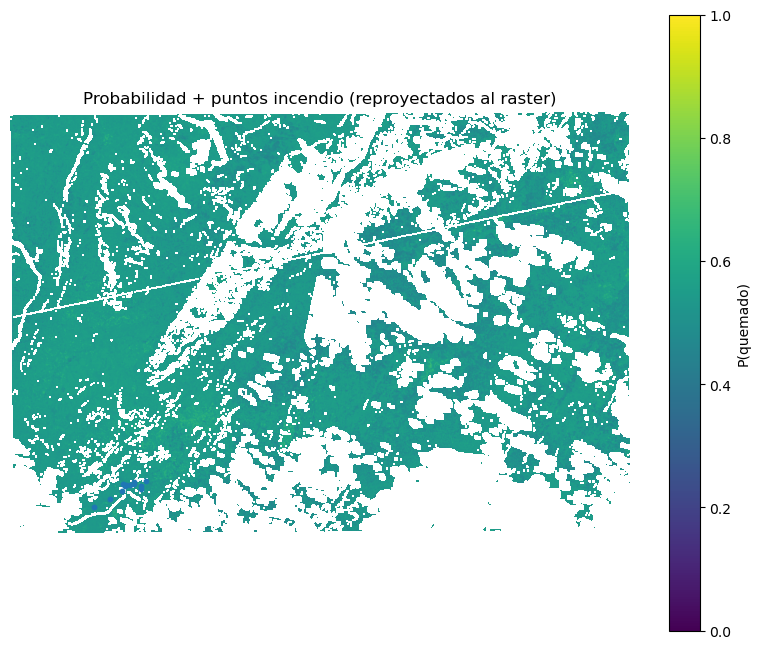

In [16]:
# ---------------------------------------------------------
# 3) Validación con puntos reales (presencia) + opcional ausencia
# ---------------------------------------------------------
g_fire = gpd.read_file(PATH_FIRE_GDB, layer=FIRE_POINTS)
p_fire = _sample_raster_at_points(OUT_PROB, g_fire)
yhat_fire = (p_fire >= THRESHOLD).astype(int)

print("\nValidación (solo incendios / presencia):")
print(f" - N puntos incendio: {len(g_fire)}")
print(f" - % predicho como quemado (TP rate sobre presencia): {100*yhat_fire.mean():.2f}%")
print(f" - Prob media en incendios: {np.nanmean(p_fire):.3f}")

# Si tienes ausencias, calculamos matriz de confusión y reporte
if ABS_POINTS:
    g_abs = gpd.read_file(ABS_POINTS)
    p_abs = _sample_raster_at_points(OUT_PROB, g_abs)
    yhat_abs = (p_abs >= THRESHOLD).astype(int)

    y_true = np.concatenate([np.ones(len(g_fire), dtype=int), np.zeros(len(g_abs), dtype=int)])
    y_pred = np.concatenate([yhat_fire, yhat_abs])

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    print("\nMatriz de confusión (0=ausencia, 1=presencia):")
    print(cm)
    print("\nReporte:")
    print(classification_report(y_true, y_pred, target_names=["absence(0)","presence(1)"], zero_division=0))

# Overlay de puntos sobre el mapa de probabilidad (solo para inspección visual)
plt.figure(figsize=(10, 8))
plt.imshow(prob, vmin=0, vmax=1)
plt.title("Probabilidad + puntos incendio (reproyectados al raster)")
plt.colorbar(label="P(quemado)")
plt.axis("off")

# Proyectar puntos al CRS del raster para dibujar en coordenadas de pixel
with rasterio.open(OUT_PROB) as src:
    gf = g_fire.to_crs(src.crs)
    # Convertir coords mundo->fila/col
    rows, cols = rasterio.transform.rowcol(src.transform, gf.geometry.x.values, gf.geometry.y.values)
    plt.scatter(cols, rows, s=10)  # puntos sobre imagen
plt.show()




In [17]:
import numpy as np
from sklearn.metrics import f1_score

# y_true: array con tus 24 etiquetas reales (0s y 1s)
# y_probs: array con las 24 probabilidades continuas predichas por el modelo

thresholds = np.linspace(0.30, 0.55, 51)
best_thresh = 0.30
best_f1 = 0.0

for t in thresholds:
    preds = (y_pred >= t).astype(int)
    score = f1_score(y_true, y_pred, pos_label=1)
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print(f"Umbral óptimo sugerido: {best_thresh:.3f} (F1-Score: {best_f1:.2f})")

Umbral óptimo sugerido: 0.300 (F1-Score: 0.15)
